In [1]:
import pandas as pd
import requests

# Dictionnaire des URLs à télécharger
urls = {
    "paludisme": "https://ourworldindata.org/grapher/incidence-of-malaria.csv?v=1&csvType=full&useColumnShortNames=false",
    "mortalite_maternelle": "https://ourworldindata.org/grapher/maternal-mortality.csv?v=1&csvType=full&useColumnShortNames=false",
    "soins_prenataux": "https://ourworldindata.org/grapher/share-of-mothers-receiving-at-least-one-antenatal-visit-during-pregnancy.csv?v=1&csvType=full&useColumnShortNames=false",
}

# Our World in Data demande un User-Agent personnalisé pour accepter la requête
headers = {"User-Agent": "Projet etudiant - Data Analysis/1.0"}

# Téléchargement et sauvegarde dans le dossier data/
for nom, url in urls.items():
    print(f"Téléchargement de : {nom}...")
    df = pd.read_csv(url, storage_options=headers)
    chemin = f"../data/{nom}.csv"
    df.to_csv(chemin, index=False)

Téléchargement de : paludisme...
Téléchargement de : mortalite_maternelle...
Téléchargement de : soins_prenataux...


In [2]:
# On recharge les fichiers sauvegardés localement
df_paludisme = pd.read_csv("../data/paludisme.csv")
#df_mortalite = pd.read_csv("../data/mortalite_maternelle.csv")
#df_prenatal = pd.read_csv("../data/soins_prenataux.csv")

In [3]:
df_paludisme.head()

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
0,Afghanistan,AFG,2000,84.48
1,Afghanistan,AFG,2001,83.83
2,Afghanistan,AFG,2002,83.79
3,Afghanistan,AFG,2003,70.81
4,Afghanistan,AFG,2004,39.41


In [4]:
df_paludisme.describe()

,Year,"Incidence of malaria (per 1,000 population at risk)"
count,2851.000000,2851.000000
mean,2011.958962,100.953004
std,7.176233,145.808320
min,2000.000000,0.000000
25%,2006.000000,0.490000
50%,2012.000000,9.920000
75%,2018.000000,195.160000
max,2024.000000,718.980000


In [5]:
df_paludisme.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2851 entries, 0 to 2850
Data columns (total 4 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               2851 non-null   object 
 1   Code                                                 2851 non-null   object 
 2   Year                                                 2851 non-null   int64  
 3   Incidence of malaria (per 1,000 population at risk)  2851 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 89.2+ KB


In [6]:
df_paludisme.shape

(2851, 4)

In [7]:
# On filtre pour ne garder que les lignes concernant le Sénégal
senegal = df_paludisme[df_paludisme["Entity"] == "Senegal"]
senegal

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
2125,Senegal,SEN,2000,230.37
2126,Senegal,SEN,2001,176.61
2127,Senegal,SEN,2002,156.98
2128,Senegal,SEN,2003,168.09
2129,Senegal,SEN,2004,129.20
2130,Senegal,SEN,2005,132.26
2131,Senegal,SEN,2006,121.53
2132,Senegal,SEN,2007,98.57
2133,Senegal,SEN,2008,52.18
2134,Senegal,SEN,2009,32.88


In [8]:
print("Nombre de lignes pour le Sénégal :", len(senegal))
print("Première année :", senegal["Year"].min())
print("Dernière année :", senegal["Year"].max())
print("\nValeurs :")
print(senegal[["Year", "Incidence of malaria (per 1,000 population at risk)"]].to_string(index=False))

Nombre de lignes pour le Sénégal : 25
Première année : 2000
Dernière année : 2024

Valeurs :
 Year  Incidence of malaria (per 1,000 population at risk)
 2000                                               230.37
 2001                                               176.61
 2002                                               156.98
 2003                                               168.09
 2004                                               129.20
 2005                                               132.26
 2006                                               121.53
 2007                                                98.57
 2008                                                52.18
 2009                                                32.88
 2010                                                60.40
 2011                                                48.31
 2012                                                53.04
 2013                                                57.87
 2014                 

In [9]:
import matplotlib.pyplot as plt
plot(Senegal)
plt.show()


NameError: name 'plot' is not defined

In [10]:
# Chargement de la base mortalité
df_mortalite = pd.read_csv("../data/mortalite_maternelle.csv")
df_mortalite

,Entity,Code,Year,Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations)
0,Afghanistan,AFG,1985,1910.3416,Asia,NaN
1,Afghanistan,AFG,1986,1602.9429,Asia,NaN
2,Afghanistan,AFG,1987,1586.7214,Asia,NaN
3,Afghanistan,AFG,1988,1413.9326,Asia,NaN
4,Afghanistan,AFG,1989,1382.7299,Asia,NaN
...,...,...,...,...,...,...
9259,Zimbabwe,ZWE,2016,399.7575,Africa,NaN
9260,Zimbabwe,ZWE,2017,366.3810,Africa,NaN
9261,Zimbabwe,ZWE,2018,358.5035,Africa,NaN
9262,Zimbabwe,ZWE,2019,393.1763,Africa,NaN


In [11]:
# Compte le nombre de valeurs non-vides dans la colonne d'annotations
print("Valeurs vides dans la colonne Annotations :",df_mortalite["Maternal mortality ratio (Annotations)"].isna().sum())
print("Valeurs non-vides dans la colonne Annotations :", df_mortalite["Maternal mortality ratio (Annotations)"].notna().sum())
print("Total de lignes :", len(df_mortalite))

Valeurs vides dans la colonne Annotations : 9143
Valeurs non-vides dans la colonne Annotations : 121
Total de lignes : 9264


In [12]:
# Affiche les lignes qui ONT une annotation (pas vides)
annotations_presentes = df_mortalite[df_mortalite["Maternal mortality ratio (Annotations)"].notna()]
print(annotations_presentes[["Entity", "Year", "Maternal mortality ratio (Annotations)"]].head(20))

# Affiche les valeurs uniques d'annotations (pour voir les types de messages possibles)
print("\n--- Valeurs uniques d'annotations ---")
print(annotations_presentes["Maternal mortality ratio (Annotations)"].unique())

             Entity  Year             Maternal mortality ratio (Annotations)
8727  United States  1900  Values from 2003–2017 affected by measurement ...
8728  United States  1901  Values from 2003–2017 affected by measurement ...
8729  United States  1902  Values from 2003–2017 affected by measurement ...
8730  United States  1903  Values from 2003–2017 affected by measurement ...
8731  United States  1904  Values from 2003–2017 affected by measurement ...
8732  United States  1905  Values from 2003–2017 affected by measurement ...
8733  United States  1906  Values from 2003–2017 affected by measurement ...
8734  United States  1907  Values from 2003–2017 affected by measurement ...
8735  United States  1908  Values from 2003–2017 affected by measurement ...
8736  United States  1909  Values from 2003–2017 affected by measurement ...
8737  United States  1910  Values from 2003–2017 affected by measurement ...
8738  United States  1911  Values from 2003–2017 affected by measurement ...

In [13]:
# Chargement de la dataset prenatal
df_prenatal = pd.read_csv("../data/soins_prenataux.csv")

In [14]:
senegal_prenatal = df_prenatal[df_prenatal["Entity"] == "Senegal"]
senegal_prenatal

,Entity,Code,Year,Pregnant women receiving prenatal care (%)
780,Senegal,SEN,1986,29.7
781,Senegal,SEN,1993,74.2
782,Senegal,SEN,1997,83.3
783,Senegal,SEN,2000,79.0
784,Senegal,SEN,2005,87.4
785,Senegal,SEN,2006,91.4
786,Senegal,SEN,2009,94.0
787,Senegal,SEN,2011,93.3
788,Senegal,SEN,2013,94.5
789,Senegal,SEN,2014,96.2


In [15]:
# FILTRAGE DES PAYS CONCENES
# Liste des 5 pays du cahier des charges
pays_afrique_ouest = ["Senegal", "Guinea", "Mali", "Burkina Faso", "Cote d'Ivoire"]

# Filtrage de chaque dataset
df_paludisme_aow = df_paludisme[df_paludisme["Entity"].isin(pays_afrique_ouest)]
df_mortalite_aow = df_mortalite[df_mortalite["Entity"].isin(pays_afrique_ouest)]
df_prenatal_aow = df_prenatal[df_prenatal["Entity"].isin(pays_afrique_ouest)]

# Vérification : combien de lignes reste-t-il pour chaque dataset ?
print("Paludisme     :", len(df_paludisme_aow), "lignes")
print("Mortalité     :", len(df_mortalite_aow), "lignes")
print("Soins prénataux:", len(df_prenatal_aow), "lignes")

Paludisme     : 125 lignes
Mortalité     : 180 lignes
Soins prénataux: 47 lignes


In [16]:
df_paludisme_aow

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
323,Burkina Faso,BFA,2000,597.17
324,Burkina Faso,BFA,2001,597.54
325,Burkina Faso,BFA,2002,592.47
326,Burkina Faso,BFA,2003,582.14
327,Burkina Faso,BFA,2004,559.01
...,...,...,...,...
2145,Senegal,SEN,2020,35.59
2146,Senegal,SEN,2021,41.85
2147,Senegal,SEN,2022,38.10
2148,Senegal,SEN,2023,34.69


In [17]:
# Renommer les colonnes pour les rendre plus courtes et lisibles
df_paludisme_propre = df_paludisme_aow.rename(columns={
    "Entity": "pays",
    "Code": "code_pays",
    "Year": "annee",
    "Incidence of malaria (per 1,000 population at risk)": "incidence_paludisme"
})

In [18]:
df_paludisme_propre.dtypes

pays                    object
code_pays               object
annee                    int64
incidence_paludisme    float64
dtype: object

In [19]:
# Statistiques descriptives du dataset paludisme
print(df_paludisme_propre.describe())


             annee  incidence_paludisme
count   125.000000           125.000000
mean   2012.000000           336.492080
std       7.240121           151.588933
min    2000.000000            32.880000
25%    2006.000000           280.220000
50%    2012.000000           374.390000
75%    2018.000000           424.290000
max    2024.000000           597.540000


In [20]:
print(df_paludisme_aow["Entity"].unique())

['Burkina Faso' "Cote d'Ivoire" 'Guinea' 'Mali' 'Senegal']


In [21]:
# ============================================================
# NETTOYAGE - Dataset 1 : Paludisme
# ============================================================

In [22]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes dans le dataset paludisme :")
df_paludisme_propre.isnull().sum()


Valeurs manquantes dans le dataset paludisme :


pays                   0
code_pays              0
annee                  0
incidence_paludisme    0
dtype: int64

In [23]:
#df_paludisme_propre["annee"]=pd.to_datetime(df_paludisme_propre["annee"],format="%Y")

In [24]:
df_paludisme_propre

,pays,code_pays,annee,incidence_paludisme
323,Burkina Faso,BFA,2000,597.17
324,Burkina Faso,BFA,2001,597.54
325,Burkina Faso,BFA,2002,592.47
326,Burkina Faso,BFA,2003,582.14
327,Burkina Faso,BFA,2004,559.01
...,...,...,...,...
2145,Senegal,SEN,2020,35.59
2146,Senegal,SEN,2021,41.85
2147,Senegal,SEN,2022,38.10
2148,Senegal,SEN,2023,34.69


In [32]:
 #1)Quel pays a la situation la plus critique  et interpretation?

In [25]:
# Quel pays/année a l'incidence la plus élevée ?
print("=== CAS LE PLUS CRITIQUE ===")
print(df_paludisme_propre.loc[df_paludisme_propre["incidence_paludisme"].idxmax()])


=== CAS LE PLUS CRITIQUE ===
pays                   Burkina Faso
code_pays                       BFA
annee                          2001
incidence_paludisme          597.54
Name: 324, dtype: object


In [ ]:
# Interpretation
Cas le plus critique : Burkina Faso en 2001 avec 597 cas pour 1000 personnes — presque 60% de
la population à risque touchée en une seule année, c'est un chiffre alarmant.

In [ ]:
# 2)Quelle est la tendance la plus favorable et interpretation

In [26]:
# Quel pays/année a l'incidence la plus basse ?
print("\n=== CAS LE PLUS FAVORABLE ===")
print(df_paludisme_propre.loc[df_paludisme_propre["incidence_paludisme"].idxmin()])



=== CAS LE PLUS FAVORABLE ===
pays                   Senegal
code_pays                  SEN
annee                     2009
incidence_paludisme      32.88
Name: 2134, dtype: object


In [ ]:
# Interpretation
Cas le plus favorable : Sénégal en 2009 avec 32 cas pour 1000 — on avait déjà remarqué
cette chute spectaculaire lors de l'exploration initiale.

In [ ]:
# 3 Quelle est la tendance générale sur la période ?

In [27]:
# Moyenne par pays sur toute la période
print("\n=== MOYENNE PAR PAYS (2000-2024) ===")
print(df_paludisme_propre.groupby("pays")["incidence_paludisme"].mean().sort_values(ascending=False).round(1))


=== MOYENNE PAR PAYS (2000-2024) ===
pays
Burkina Faso     475.0
Mali             383.5
Guinea           376.2
Cote d'Ivoire    367.1
Senegal           80.7
Name: incidence_paludisme, dtype: float64


In [ ]:
# Quelle est Evolution temporelle par pays

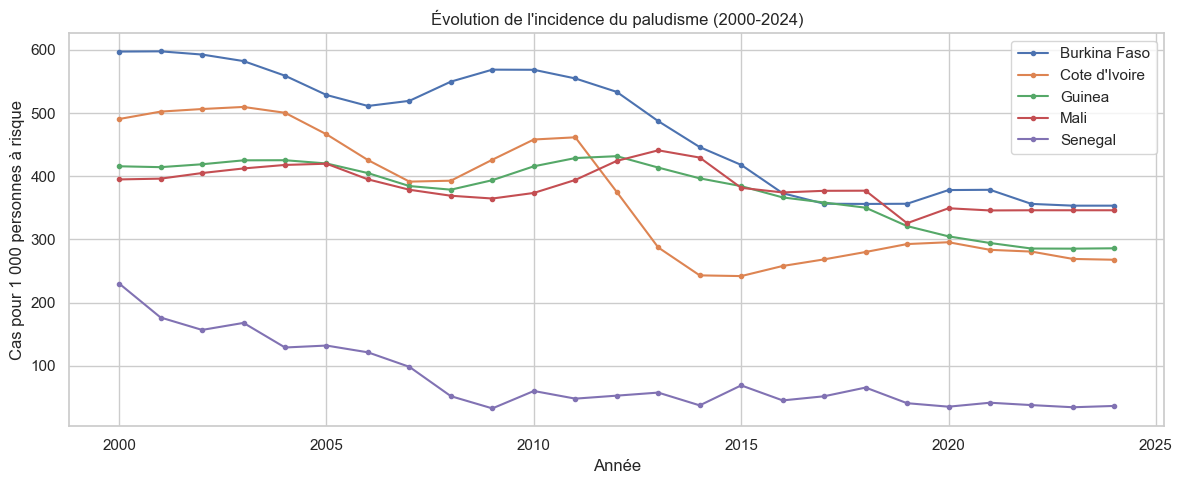

Graphique sauvegardé dans exports/


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration générale des graphiques
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="whitegrid")

# --- Graphique 1 : Evolution temporelle par pays ---
plt.figure()
for pays in df_paludisme_propre["pays"].unique():
    data_pays = df_paludisme_propre[df_paludisme_propre["pays"] == pays]
    plt.plot(data_pays["annee"], data_pays["incidence_paludisme"], marker="o", markersize=3, label=pays)

plt.title("Évolution de l'incidence du paludisme (2000-2024)")
plt.xlabel("Année")
plt.ylabel("Cas pour 1 000 personnes à risque")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../exports/graphique_paludisme_evolution.png", dpi=150)
plt.show()
print("Graphique sauvegardé dans exports/")

In [ ]:
# Quelle est la moyenne incidente la plus elevee?

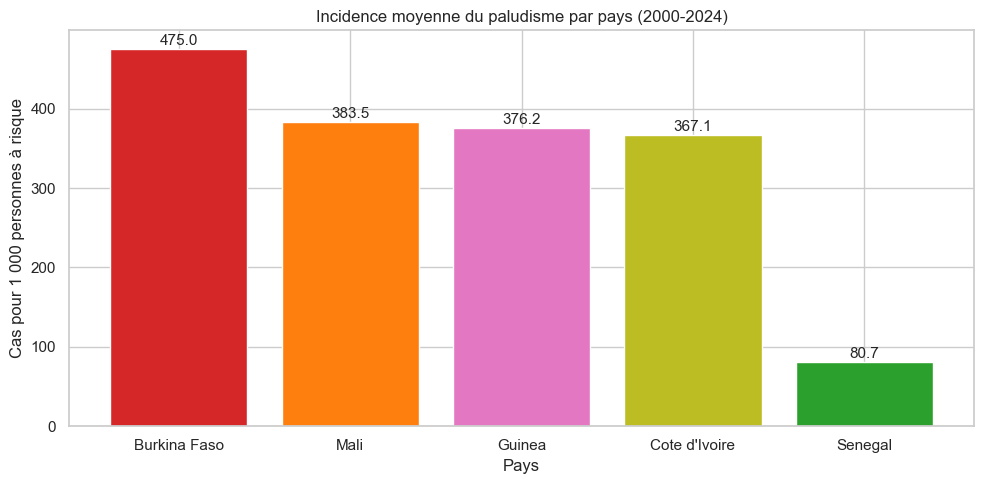

Graphique sauvegardé dans exports/


In [29]:
# --- Graphique 2 : Comparaison des moyennes par pays ---
moyenne_par_pays = df_paludisme_propre.groupby("pays")["incidence_paludisme"].mean().sort_values(ascending=False).round(1)

plt.figure(figsize=(10, 5))
barres = plt.bar(moyenne_par_pays.index, moyenne_par_pays.values, color=["#d62728", "#ff7f0e", "#e377c2", "#bcbd22", "#2ca02c"])

# Ajouter les valeurs au dessus de chaque barre
for barre in barres:
    hauteur = barre.get_height()
    plt.text(barre.get_x() + barre.get_width() / 2, hauteur + 5, f"{hauteur:.1f}", ha="center", fontsize=11)

plt.title("Incidence moyenne du paludisme par pays (2000-2024)")
plt.xlabel("Pays")
plt.ylabel("Cas pour 1 000 personnes à risque")
plt.tight_layout()
plt.savefig("../exports/graphique_paludisme_barres.png", dpi=150)
plt.show()
print("Graphique sauvegardé dans exports/")

In [ ]:
Récapitulatif EDA Paludisme — ce qu'on retiendra pour le rapport
Voici les insights clés à noter quelque part (bloc-notes, Word...) pour ton rapport technique :

Le Sénégal se distingue nettement avec une moyenne de 80 cas/1000, soit 4 à 6 fois moins que les autres pays
Burkina Faso est le pays le plus touché avec une moyenne de 475 cas/1000 et un pic à 597 en 2001
Tendance globale à la baisse sur la période 2000-2024, probablement liée aux campagnes de distribution 
de moustiquaires et aux traitements préventifs
Les données sont complètes — 25 années sans aucune valeur manquante pour les 5 pays

In [ ]:
# ============================================================
# NETTOYAGE - Dataset 2 : Mortalité maternelle
# ============================================================

In [35]:
df_mortalite_propre = df_mortalite_aow.drop(columns=[
    "Maternal mortality ratio (Annotations)"
]).rename(columns={
    "Entity": "pays",
    "Code": "code_pays",
    "Year": "annee",
    "Maternal mortality ratio": "taux_mortalite_maternelle",
    "World region according to OWID": "region_monde"
})

# Vérifier les valeurs manquantes
print("Valeurs manquantes :")
print(df_mortalite_propre.isnull().sum())

# Aperçu
print("\nAperçu :")
df_mortalite_propre.sample(10)

Valeurs manquantes :
pays                         0
code_pays                    0
annee                        0
taux_mortalite_maternelle    0
region_monde                 0
dtype: int64

Aperçu :


,pays,code_pays,annee,taux_mortalite_maternelle,region_monde
7008,Senegal,SEN,2000,638.37195,Africa
3327,Guinea,GIN,2011,744.27490,Africa
7005,Senegal,SEN,1997,606.48420,Africa
3314,Guinea,GIN,1998,922.77780,Africa
1819,Cote d'Ivoire,CIV,2002,519.81730,Africa
1290,Burkina Faso,BFA,2012,320.79483,Africa
7028,Senegal,SEN,2020,260.88060,Africa
3318,Guinea,GIN,2002,928.56110,Africa
1274,Burkina Faso,BFA,1996,614.25415,Africa
7011,Senegal,SEN,2003,564.80350,Africa


In [ ]:
Aucune valeur manquante et la structure est propre. On remarque que les données commencent en 1985 pour Burkina Faso 
— on verra si c'est pareil pour tous les pays.

In [36]:
# Statistiques descriptives
print("=== STATISTIQUES DESCRIPTIVES ===")
print(df_mortalite_propre.describe())

# Période couverte par pays
print("\n=== PÉRIODE PAR PAYS ===")
print(df_mortalite_propre.groupby("pays")["annee"].agg(["min", "max", "count"]))

=== STATISTIQUES DESCRIPTIVES ===
             annee  taux_mortalite_maternelle
count   180.000000                 180.000000
mean   2002.500000                 641.320276
std      10.417272                 240.650064
min    1985.000000                 257.611480
25%    1993.750000                 493.026200
50%    2002.500000                 588.054825
75%    2011.250000                 744.278288
max    2020.000000                1341.181200

=== PÉRIODE PAR PAYS ===
                min   max  count
pays                            
Burkina Faso   1985  2020     36
Cote d'Ivoire  1985  2020     36
Guinea         1985  2020     36
Mali           1985  2020     36
Senegal        1985  2020     36


In [ ]:
# Annalyse du resultat observé
Très bien, les données sont parfaitement symétriques — tous les 5 pays ont exactement 36 années de données (1985 à 2020), 
sans aucun trou. C'est idéal.

In [ ]:
# Quelle est: AS LE PLUS CRITIQUE , CAS LE PLUS FAVORABLE et MOYENNE PAR PAYS (1985-2020)

In [39]:
# Cas le plus critique
print("=== CAS LE PLUS CRITIQUE ===")
print(df_mortalite_propre.loc[df_mortalite_propre["taux_mortalite_maternelle"].idxmax()])

# Cas le plus favorable
print("\n=== CAS LE PLUS FAVORABLE ===")
print(df_mortalite_propre.loc[df_mortalite_propre["taux_mortalite_maternelle"].idxmin()])

# Moyenne par pays sur toute la période
print("\n=== MOYENNE PAR PAYS (1985-2020) ===")
print(df_mortalite_propre.groupby("pays")["taux_mortalite_maternelle"].mean().sort_values(ascending=False).round(1))

=== CAS LE PLUS CRITIQUE ===
pays                              Mali
code_pays                          MLI
annee                             1985
taux_mortalite_maternelle    1341.1812
region_monde                    Africa
Name: 4977, dtype: object

=== CAS LE PLUS FAVORABLE ===
pays                           Senegal
code_pays                          SEN
annee                             2019
taux_mortalite_maternelle    257.61148
region_monde                    Africa
Name: 7027, dtype: object

=== MOYENNE PAR PAYS (1985-2020) ===
pays
Guinea           888.7
Mali             749.0
Cote d'Ivoire    554.8
Senegal          509.6
Burkina Faso     504.5
Name: taux_mortalite_maternelle, dtype: float64


In [ ]:
# Interpretation des resultats obtenus

In [ ]:
Ce que révèlent ces chiffres
Cas le plus critique : Mali en 1985 avec 1341 décès pour 100 000 naissances —
un chiffre catastrophique, mais qui date de 40 ans.
On va vérifier si la situation s'est améliorée depuis.
Cas le plus favorable : Sénégal en 2019 avec 257 décès pour 100 000 
— c'est encore très élevé comparé aux standards mondiaux, mais c'est le meilleur
résultat de notre région sur toute la période.

Contrairement au paludisme, le Sénégal n'est pas aussi nettement supérieur aux autres 
— il est 4ème sur 5, très proche de Burkina Faso
La Guinée est le pays le plus touché pour la mortalité maternelle, alors que c'était Burkina Faso pour le paludisme
— chaque indicateur raconte une histoire différente, c'est exactement ce que le dashboard doit mettre en valeur

In [ ]:
# Visualisation des resultats obtenus

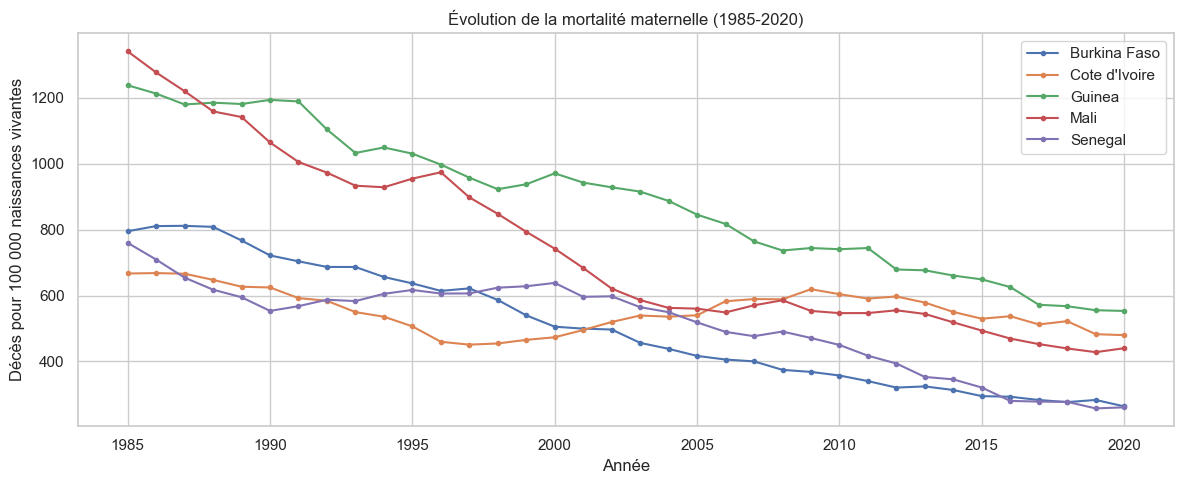

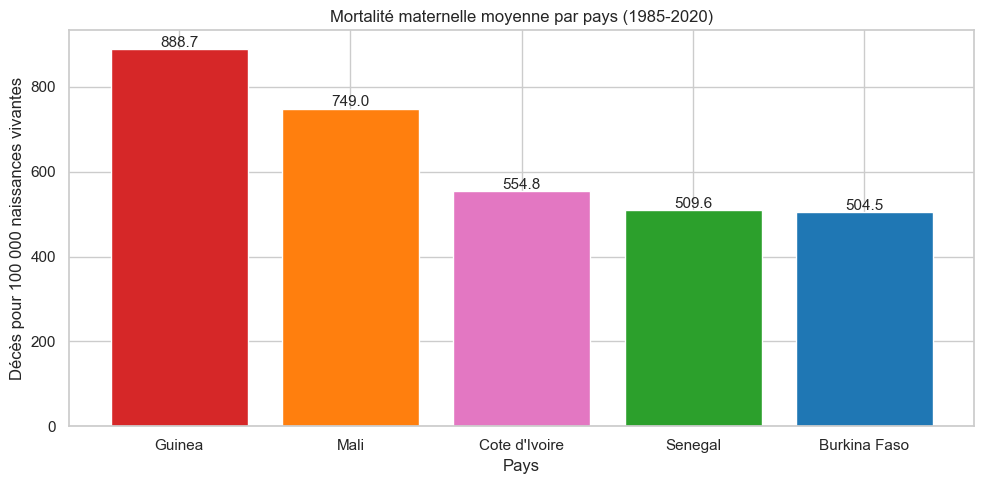

Graphiques sauvegardés dans exports/


In [40]:
# --- Graphique 1 : Évolution temporelle par pays ---
plt.figure(figsize=(12, 5))
for pays in df_mortalite_propre["pays"].unique():
    data_pays = df_mortalite_propre[df_mortalite_propre["pays"] == pays]
    plt.plot(data_pays["annee"], data_pays["taux_mortalite_maternelle"], marker="o", markersize=3, label=pays)

plt.title("Évolution de la mortalité maternelle (1985-2020)")
plt.xlabel("Année")
plt.ylabel("Décès pour 100 000 naissances vivantes")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../exports/graphique_mortalite_evolution.png", dpi=150)
plt.show()

# --- Graphique 2 : Moyenne par pays ---
moyenne_mortalite = df_mortalite_propre.groupby("pays")["taux_mortalite_maternelle"].mean().sort_values(ascending=False).round(1)

plt.figure(figsize=(10, 5))
barres = plt.bar(moyenne_mortalite.index, moyenne_mortalite.values,
                 color=["#d62728", "#ff7f0e", "#e377c2", "#2ca02c", "#1f77b4"])

for barre in barres:
    hauteur = barre.get_height()
    plt.text(barre.get_x() + barre.get_width() / 2, hauteur + 5,
             f"{hauteur:.1f}", ha="center", fontsize=11)

plt.title("Mortalité maternelle moyenne par pays (1985-2020)")
plt.xlabel("Pays")
plt.ylabel("Décès pour 100 000 naissances vivantes")
plt.tight_layout()
plt.savefig("../exports/graphique_mortalite_barres.png", dpi=150)
plt.show()

print("Graphiques sauvegardés dans exports/")

In [ ]:
# Récapitulatif EDA Mortalité maternelle — à noter pour le rapport

La Guinée est le pays le plus touché avec une moyenne de 888 décès/100 000, loin devant les autres
Le Mali avait la situation la plus catastrophique en 1985 avec 1341 décès/100 000, mais la tendance montre une amélioration progressive
Le Sénégal est le meilleur élève avec le record le plus bas en 2019 à 257 décès/100 000
Tendance globale à la baisse pour tous les pays sur 1985-2020 — les efforts en santé maternelle portent leurs fruits, mais les chiffres restent très élevés
Données complètes — 36 années consécutives sans valeur manquante pour les 5 pay

In [44]:
# ============================================================
# NETTOYAGE - Dataset 3 : Soins prénataux
# ============================================================

df_prenatal_propre = df_prenatal_aow.rename(columns={
    "Entity": "pays",
    "Code": "code_pays",
    "Year": "annee",
    "Pregnant women receiving prenatal care (%)": "couverture_prenatale"
})

# Vérifier les valeurs manquantes
print("Valeurs manquantes :")
print(df_prenatal_propre.isnull().sum())

# Aperçu
print("\nAperçu :")
print(df_prenatal_propre.head())

Valeurs manquantes :
pays                    0
code_pays               0
annee                   0
couverture_prenatale    0
dtype: int64

Aperçu :
             pays code_pays  annee  couverture_prenatale
130  Burkina Faso       BFA   1993                  60.0
131  Burkina Faso       BFA   1999                  63.0
132  Burkina Faso       BFA   2003                  73.4
133  Burkina Faso       BFA   2006                  85.0
134  Burkina Faso       BFA   2010                  94.3


In [45]:
# Statistiques descriptives
print("=== STATISTIQUES DESCRIPTIVES ===")
print(df_prenatal_propre.describe())

# Période et nombre de points par pays
print("\n=== PÉRIODE ET POINTS DE DONNÉES PAR PAYS ===")
print(df_prenatal_propre.groupby("pays")["annee"].agg(["min", "max", "count"]))

=== STATISTIQUES DESCRIPTIVES ===
             annee  couverture_prenatale
count    47.000000             47.000000
mean   2006.702128             79.261702
std       8.895321             18.138268
min    1986.000000             29.700000
25%    2000.000000             73.850000
50%    2007.000000             84.800000
75%    2014.500000             93.000000
max    2019.000000             97.700000

=== PÉRIODE ET POINTS DE DONNÉES PAR PAYS ===
                min   max  count
pays                            
Burkina Faso   1993  2018      8
Cote d'Ivoire  1994  2016      7
Guinea         1992  2018      9
Mali           1987  2018      8
Senegal        1986  2019     15


In [ ]:
Ce que disent ces statistiques
Sur la couverture prénatale :

mean = 79% → en moyenne 79% des femmes enceintes ont eu au moins une visite prénatale sur l'ensemble des pays et des années
min = 29.7% → c'était le Sénégal en 1986, on l'avait déjà vu
max = 97.7% → quasi-universelle, c'était aussi le Sénégal en 2018
50% = 84.8% → la moitié des observations dépassent 84%, ce qui indique une amélioration globale sur la période

In [ ]:
# Visualisation des resultats obtenus

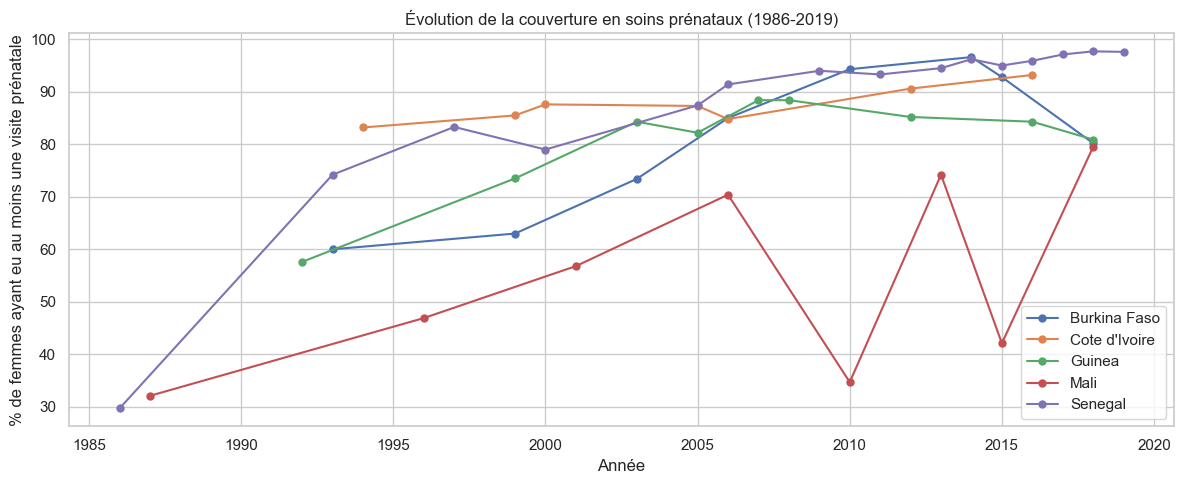

C:\Users\ABDOULAYE NDOUR\AppData\Local\Temp\ipykernel_18808\1962367439.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  derniere_valeur = df_prenatal_propre.groupby("pays").apply(


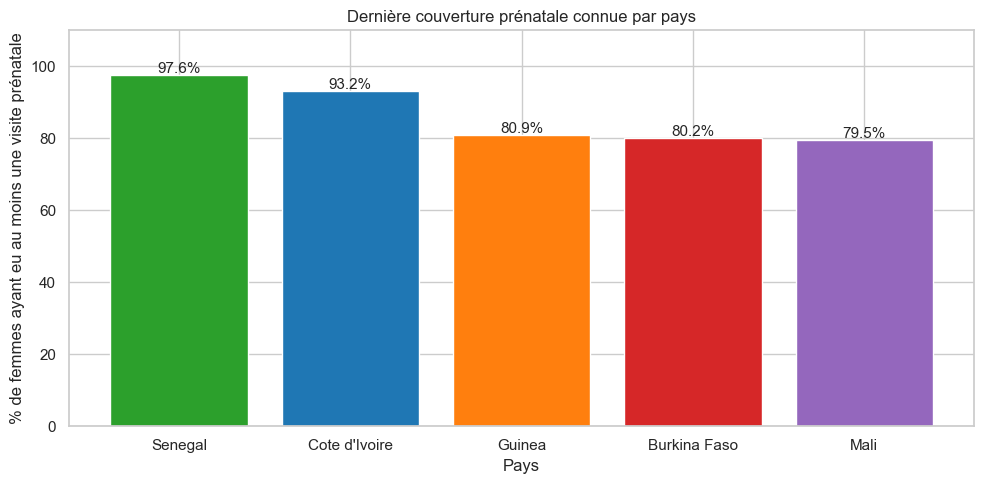

Graphiques sauvegardés dans exports/


In [46]:
# --- Graphique 1 : Évolution temporelle par pays ---
plt.figure(figsize=(12, 5))
for pays in df_prenatal_propre["pays"].unique():
    data_pays = df_prenatal_propre[df_prenatal_propre["pays"] == pays]
    plt.plot(data_pays["annee"], data_pays["couverture_prenatale"],
             marker="o", markersize=5, label=pays, linewidth=1.5)

plt.title("Évolution de la couverture en soins prénataux (1986-2019)")
plt.xlabel("Année")
plt.ylabel("% de femmes ayant eu au moins une visite prénatale")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../exports/graphique_prenatal_evolution.png", dpi=150)
plt.show()

# --- Graphique 2 : Dernière valeur disponible par pays ---
derniere_valeur = df_prenatal_propre.groupby("pays").apply(
    lambda x: x.loc[x["annee"].idxmax(), "couverture_prenatale"]
).sort_values(ascending=False).round(1)

plt.figure(figsize=(10, 5))
barres = plt.bar(derniere_valeur.index, derniere_valeur.values,
                 color=["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "#9467bd"])

for barre in barres:
    hauteur = barre.get_height()
    plt.text(barre.get_x() + barre.get_width() / 2, hauteur + 0.5,
             f"{hauteur:.1f}%", ha="center", fontsize=11)

plt.title("Dernière couverture prénatale connue par pays")
plt.xlabel("Pays")
plt.ylabel("% de femmes ayant eu au moins une visite prénatale")
plt.ylim(0, 110)
plt.tight_layout()
plt.savefig("../exports/graphique_prenatal_barres.png", dpi=150)
plt.show()

print("Graphiques sauvegardés dans exports/")

In [ ]:
Récapitulatif EDA Soins prénataux — à noter pour le rapport

1-Progression spectaculaire au Sénégal : de 29.7% en 1986 à 97.7% en 2018 — la meilleure trajectoire de la région
2-Tous les pays montrent une tendance à la hausse — signe d'amélioration générale de l'accès aux soins maternels
3-Données irrégulières — basées sur des enquêtes ponctuelles (EDS), pas de suivi annuel continu
4-Aucune donnée après 2019 

In [ ]:
# Nettoyage final des datasets

In [48]:
# Vérification finale des 3 datasets avant export
print("=== VÉRIFICATION FINALE ===")
print("\n--- PALUDISME ---")
print(f"Forme : {df_paludisme_propre.shape}")
print(f"Colonnes : {list(df_paludisme_propre.columns)}")
print(f"Pays : {sorted(df_paludisme_propre['pays'].unique())}")
print(f"Période : {df_paludisme_propre['annee'].min()} - {df_paludisme_propre['annee'].max()}")

print("\n--- MORTALITÉ MATERNELLE ---")
print(f"Forme : {df_mortalite_propre.shape}")
print(f"Colonnes : {list(df_mortalite_propre.columns)}")
print(f"Pays : {sorted(df_mortalite_propre['pays'].unique())}")
print(f"Période : {df_mortalite_propre['annee'].min()} - {df_mortalite_propre['annee'].max()}")

print("\n--- SOINS PRÉNATAUX ---")
print(f"Forme : {df_prenatal_propre.shape}")
print(f"Colonnes : {list(df_prenatal_propre.columns)}")
print(f"Pays : {sorted(df_prenatal_propre['pays'].unique())}")
print(f"Période : {df_prenatal_propre['annee'].min()} - {df_prenatal_propre['annee'].max()}")

=== VÉRIFICATION FINALE ===

--- PALUDISME ---
Forme : (125, 4)
Colonnes : ['pays', 'code_pays', 'annee', 'incidence_paludisme']
Pays : ['Burkina Faso', "Cote d'Ivoire", 'Guinea', 'Mali', 'Senegal']
Période : 2000 - 2024

--- MORTALITÉ MATERNELLE ---
Forme : (180, 5)
Colonnes : ['pays', 'code_pays', 'annee', 'taux_mortalite_maternelle', 'region_monde']
Pays : ['Burkina Faso', "Cote d'Ivoire", 'Guinea', 'Mali', 'Senegal']
Période : 1985 - 2020

--- SOINS PRÉNATAUX ---
Forme : (47, 4)
Colonnes : ['pays', 'code_pays', 'annee', 'couverture_prenatale']
Pays : ['Burkina Faso', "Cote d'Ivoire", 'Guinea', 'Mali', 'Senegal']
Période : 1986 - 2019


In [49]:
# ============================================================
# EXPORT DES 3 DATASETS NETTOYÉS EN FORMAT EXCEL
# ============================================================

# Export paludisme
df_paludisme_propre.to_excel("../exports/paludisme_propre.xlsx", index=False)
print("✅ paludisme_propre.xlsx exporté")

# Export mortalité maternelle
df_mortalite_propre.to_excel("../exports/mortalite_maternelle_propre.xlsx", index=False)
print("✅ mortalite_maternelle_propre.xlsx exporté")

# Export soins prénataux
df_prenatal_propre.to_excel("../exports/soins_prenataux_propre.xlsx", index=False)
print("✅ soins_prenataux_propre.xlsx exporté")

print("\nTous les fichiers sont dans le dossier exports/")
print("Ils sont prêts à être importés dans Power BI Desktop.")

✅ paludisme_propre.xlsx exporté
✅ mortalite_maternelle_propre.xlsx exporté
✅ soins_prenataux_propre.xlsx exporté

Tous les fichiers sont dans le dossier exports/
Ils sont prêts à être importés dans Power BI Desktop.
